# Atmosphere Rendering Experiments

This notebook is the working area for the final project. The immediate goal is to keep a minimal rendering loop and a simple atmosphere-like baseline so the shader implementation can be iterated on incrementally.

Planned milestones:
- Replace the placeholder emission-absorption volume with an analytic atmosphere density model
- Add optical depth integration along the view ray and light ray
- Add Rayleigh and Mie phase functions
- Sweep sun angle and scattering parameters for comparison renders


In [56]:
import open3d as o3d
import slangpy as spy
from pyglm import glm
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "from_asst3" / "asst3" / "src"))
for name in list(sys.modules):
    if name == "cs248a_renderer" or name.startswith("cs248a_renderer."):
        del sys.modules[name]
from cs248a_renderer import setup_device, RendererModules
from cs248a_renderer.model.bvh import BVH
from cs248a_renderer.model.scene import Scene
from cs248a_renderer.model.mesh import Mesh
from cs248a_renderer.model.volumes import DenseVolume
from cs248a_renderer.model.transforms import Transform3D
from cs248a_renderer.model.material import PhysicsBasedMaterial, MaterialField, BRDFType
from cs248a_renderer.model.lights import PointLight, DirectionalLight, RectangularLight
from cs248a_renderer.renderer.core_renderer import Renderer
from cs248a_renderer.view_model.scene_manager import SceneManager

import inspect
print(inspect.getsourcefile(Renderer))
print(hasattr(Renderer, "clear_render_target"))
print(Renderer)


/home/waynechu/Documents/Stanford/CS248A/final_project/from_asst3/asst3/src/cs248a_renderer/renderer/core_renderer.py
True
<class 'cs248a_renderer.renderer.core_renderer.Renderer'>


In [57]:
# Device and module setup.
device = setup_device([])
renderer_modules = RendererModules(device)


[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] Slang compiler warnings:
/home/waynechu/Documents/Stanford/CS248A/final_project/from_asst3/asst3/src/cs248a_renderer/slang_shaders/./texture/texture.slang(33): warning 41000: unreachable code detected
        return outV;
        ^~~~~~



In [58]:
# Output texture setup.
OUTPUT_IMG_SIZE = (512, 512)
output_image = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    usage=spy.TextureUsage.unordered_access,
    width=OUTPUT_IMG_SIZE[0],
    height=OUTPUT_IMG_SIZE[1],
)

renderer = Renderer(
    device=device,
    render_texture=output_image,
    render_modules=renderer_modules,
)
renderer.sqrt_spp = 1


In [59]:
def tone_mapping(image_np, gamma=2.2, exposure_time=1.0):
    gamma_corrected = np.power(np.clip(image_np[:, :, :3] * exposure_time, 0.0, None), 1.0 / gamma)
    return np.clip(gamma_corrected, 0.0, 1.0)

def build_bvh(scene):
    MAX_NODES = 8192
    triangles, materials = scene.extract_triangles_with_material()
    tqdm_bar = tqdm(total=MAX_NODES)
    def on_progress(current: int, total: int) -> None:
        tqdm_bar.n = current
        tqdm_bar.refresh()
    bvh = BVH(
        primitives=triangles,
        max_nodes=MAX_NODES,
        min_prim_per_node=4,
        on_progress=on_progress
    )

    return bvh, triangles, materials


def save_image(image_np, path, gamma=2.2, exposure_time=1.0):
    mapped = tone_mapping(image_np, gamma=gamma, exposure_time=exposure_time)
    image = Image.fromarray((mapped * 255).astype(np.uint8))
    image.save(path)


## Render Scene

In [60]:
# Load and configure the Earth / Mars / Jupiter scene
RESOURCE_DIR = Path.cwd().parents[1] / "resources"
SCENE_PATH = RESOURCE_DIR / "earth.zip"

scene_manager = SceneManager()
scene_manager.deserialize_scene(SCENE_PATH)
scene = scene_manager.scene

REALISM_NOTE = "Using real relative planet radii and compressed interplanet distances for visualization."
print(REALISM_NOTE)

PLANET_CONFIGS = {
    "earth": {
        "position": (0.0, 0.0, 0.0),
        "scale": (1.0, 1.0, 1.0),
        "albedo": (0.30, 0.43, 0.60),
        "atmosphere_enabled": True,
        "atmosphere_rayleigh_scattering_color": (0.36, 0.58, 1.00),
        "atmosphere_mie_scattering_color": (1.00, 0.95, 0.88),
        "atmosphere_absorption_color": (0.02, 0.03, 0.06),
        "atmosphere_rayleigh_density_falloff": 8.0,
        "atmosphere_mie_density_falloff": 1.2,
        "atmosphere_rayleigh_strength": 2.6,
        "atmosphere_mie_strength": 0.18,
        "atmosphere_phase_g": 0.76,
        "atmosphere_planet_radius": 1.0,
        "atmosphere_thickness": 0.016,
    },
    "mars": {
        "position": (24.0, 1.8, -10.0),
        "scale": (0.532, 0.532, 0.532),
        "albedo": (0.66, 0.39, 0.27),
        "atmosphere_enabled": True,
        "atmosphere_rayleigh_scattering_color": (0.96, 0.63, 0.47),
        "atmosphere_mie_scattering_color": (0.98, 0.72, 0.52),
        "atmosphere_absorption_color": (0.10, 0.05, 0.03),
        "atmosphere_rayleigh_density_falloff": 10.0,
        "atmosphere_mie_density_falloff": 2.5,
        "atmosphere_rayleigh_strength": 0.20,
        "atmosphere_mie_strength": 0.08,
        "atmosphere_phase_g": 0.70,
        "atmosphere_planet_radius": 0.532,
        "atmosphere_thickness": 0.004,
    },
    "jupiter": {
        "position": (-95.0, -8.0, -70.0),
        "scale": (11.21, 11.21, 11.21),
        "albedo": (0.82, 0.73, 0.62),
        "atmosphere_enabled": True,
        "atmosphere_rayleigh_scattering_color": (0.95, 0.84, 0.68),
        "atmosphere_mie_scattering_color": (1.00, 0.90, 0.78),
        "atmosphere_absorption_color": (0.12, 0.08, 0.04),
        "atmosphere_rayleigh_density_falloff": 2.2,
        "atmosphere_mie_density_falloff": 0.9,
        "atmosphere_rayleigh_strength": 0.55,
        "atmosphere_mie_strength": 0.85,
        "atmosphere_phase_g": 0.82,
        "atmosphere_planet_radius": 11.21,
        "atmosphere_thickness": 0.045,
    },
}

SUN_CONFIG = {
    "position": (60.0, 25.0, 40.0),
    "color": (1.0, 1.0, 1.0),
    "intensity": 40000.0,
}

CAMERA_CONFIG = {
    "position": (-6.5/2, 2.8/2, 5.8/2),
    "target": (0.0, 1.5, 0.0),
    "fov": 35.0,
}

def _vec3(values):
    return glm.vec3(*values)

def _look_at_rotation(position, target, up=(0.0, 1.0, 0.0)):
    view_mat = glm.lookAt(_vec3(position), _vec3(target), _vec3(up))
    camera_transform = glm.inverse(view_mat)
    return glm.quat_cast(glm.mat3(camera_transform))

def configure_planet(mesh, config):
    mesh.transform.position = _vec3(config["position"])
    mesh.transform.scale = _vec3(config["scale"])

    material = mesh.material
    if "albedo" in config:
        material.albedo.uniform_value = _vec3(config["albedo"])

    atmosphere_keys = [
        "atmosphere_enabled",
        "atmosphere_rayleigh_scattering_color",
        "atmosphere_mie_scattering_color",
        "atmosphere_absorption_color",
        "atmosphere_rayleigh_density_falloff",
        "atmosphere_mie_density_falloff",
        "atmosphere_rayleigh_strength",
        "atmosphere_mie_strength",
        "atmosphere_phase_g",
        "atmosphere_planet_radius",
        "atmosphere_thickness",
    ]
    for key in atmosphere_keys:
        if key not in config:
            continue
        value = config[key]
        if isinstance(value, tuple):
            value = _vec3(value)
        setattr(material, key, value)

def apply_scene_configuration(scene, planet_configs, sun_config=None, camera_config=None):
    for name, config in planet_configs.items():
        mesh = scene[name]
        if mesh is None:
            print(f"Missing mesh: {name}")
            continue
        configure_planet(mesh, config)

    if sun_config is not None and len(scene.point_lights) > 0:
        sun = scene.point_lights[0]
        sun.transform.position = _vec3(sun_config["position"])
        sun.color = _vec3(sun_config.get("color", (1.0, 1.0, 1.0)))
        sun.intensity = sun_config.get("intensity", sun.intensity)

    if camera_config is not None:
        scene.camera.transform.position = _vec3(camera_config["position"])
        if "target" in camera_config:
            scene.camera.transform.rotation = _look_at_rotation(
                camera_config["position"],
                camera_config["target"],
            )
        scene.camera.fov = camera_config.get("fov", scene.camera.fov)

    return scene

scene = apply_scene_configuration(
    scene,
    PLANET_CONFIGS,
    sun_config=SUN_CONFIG,
    camera_config=CAMERA_CONFIG,
)

for planet_name in ["earth", "mars", "jupiter"]:
    mesh = scene[planet_name]
    print(
        planet_name,
        "position=", tuple(round(v, 3) for v in mesh.transform.position.to_list()),
        "scale=", tuple(round(v, 3) for v in mesh.transform.scale.to_list()),
        "radius=", round(mesh.material.atmosphere_planet_radius, 3),
        "thickness=", round(mesh.material.atmosphere_thickness, 3),
    )

Using real relative planet radii and compressed interplanet distances for visualization.
earth position= (0.0, 0.0, 0.0) scale= (1.0, 1.0, 1.0) radius= 1.0 thickness= 0.016
mars position= (24.0, 1.8, -10.0) scale= (0.532, 0.532, 0.532) radius= 0.532 thickness= 0.004
jupiter position= (-95.0, -8.0, -70.0) scale= (11.21, 11.21, 11.21) radius= 11.21 thickness= 0.045


In [61]:
OUTPUT_IMG_SIZE = (800, 600)
output_image = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    usage=spy.TextureUsage.unordered_access,
    width=OUTPUT_IMG_SIZE[0],
    height=OUTPUT_IMG_SIZE[1],
)
renderer = Renderer(
    device=device,
    render_texture=output_image,
    render_modules=renderer_modules
)

In [62]:
# Build BVH for the scene
bvh, triangles, materials = build_bvh(scene)
renderer.load_bvh(triangles, bvh)
renderer.load_materials(materials)
renderer.load_lights(scene=scene)

 20%|█▉        | 1601/8192 [00:00<00:03, 2137.61it/s]


In [63]:
spp = 16
renderer.clear_render_target()
for i in tqdm(range(spp)):
    renderer.render_step(
        scene.camera.view_matrix(),
        scene.camera.fov,
        smooth_shading=True,
        path_trace_depth=4,
    )

  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:02<00:00,  7.40it/s]


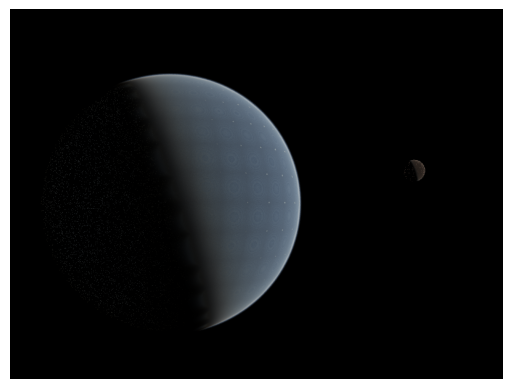

In [64]:
plt.imshow(np.clip(np.flipud(tone_mapping(output_image.to_numpy(), exposure_time=1.0)), 0, 1))
plt.axis('off')
plt.show()

# Save the rendered image
image = Image.fromarray((np.clip(np.flipud(tone_mapping(output_image.to_numpy(), exposure_time=1.0)), 0, 1) * 255).astype(np.uint8))
image.save("earth_scene.png")

## Earth Camera Animation

In [11]:
def make_orbit_view(target, radius, azimuth_deg, elevation_deg):
    azimuth = np.deg2rad(azimuth_deg)
    elevation = np.deg2rad(elevation_deg)

    position = glm.vec3(
        target.x + radius * np.cos(elevation) * np.cos(azimuth),
        target.y + radius * np.sin(elevation),
        target.z + radius * np.cos(elevation) * np.sin(azimuth),
    )

    up = glm.vec3(0.0, 1.0, 0.0)
    if abs(abs(np.sin(elevation)) - 1.0) < 1e-4:
        up = glm.vec3(0.0, 0.0, 1.0)

    return position, glm.lookAt(position, target, up)

def render_animation_frame(view_matrix, spp=48, exposure_time=1.0):
    renderer.clear_render_target()
    for _ in tqdm(range(spp), leave=False):
        renderer.render_step(
            view_matrix,
            scene.camera.fov,
            smooth_shading=True,
            path_trace_depth=4,
        )
    frame = np.clip(np.flipud(tone_mapping(output_image.to_numpy(), exposure_time=exposure_time)), 0, 1)
    return (frame * 255).astype(np.uint8)

ANIMATION_CONFIG = {
    "num_frames": 300,
    "fps": 24,
    "orbit_radius": 7.5,
    "elevation_deg": 18.0,
    "start_azimuth_deg": -35.0,
    "end_azimuth_deg": 325.0,
    "spp": 8,
    "exposure_time": 1.0,
    "output_path": Path("earth_orbit.gif"),
}

earth_mesh = scene["earth"]
earth_target = glm.vec3(earth_mesh.transform.position)
azimuths = np.linspace(
    ANIMATION_CONFIG["start_azimuth_deg"],
    ANIMATION_CONFIG["end_azimuth_deg"],
    ANIMATION_CONFIG["num_frames"],
    endpoint=False,
)

frames = []
camera_positions = []

for azimuth_deg in tqdm(azimuths, desc="Rendering Earth orbit frames"):
    camera_position, view_matrix = make_orbit_view(
        earth_target,
        ANIMATION_CONFIG["orbit_radius"],
        azimuth_deg,
        ANIMATION_CONFIG["elevation_deg"],
    )
    camera_positions.append(camera_position)
    frames.append(
        render_animation_frame(
            view_matrix,
            spp=ANIMATION_CONFIG["spp"],
            exposure_time=ANIMATION_CONFIG["exposure_time"],
        )
    )

output_path = ANIMATION_CONFIG["output_path"]
pil_frames = [Image.fromarray(frame) for frame in frames]
frame_duration_ms = int(1000 / ANIMATION_CONFIG["fps"])
pil_frames[0].save(
    output_path,
    save_all=True,
    append_images=pil_frames[1:],
    duration=frame_duration_ms,
    loop=0,
)

scene.camera.transform.position = camera_positions[-1]
print(f"Saved animation to {output_path.resolve()}")

Rendering Earth orbit frames: 100%|██████████| 300/300 [01:43<00:00,  2.91it/s]


Saved animation to /home/waynechu/Documents/Stanford/CS248A/final_project/notebooks/final_project/earth_orbit.gif
